# 08 - Average fetal ECG reconstruction

Goal: use the detected fetal QRS positions to average aligned `S5` segments and obtain `S6`, an average fetal ECG waveform.

## Why this step is needed

A single fetal ECG beat is small and noisy in abdominal recordings. After fetal QRS detection, we know approximately where the fetal beats are. If we cut many short `S5` segments around those beats, align them on the fetal QRS, and average them, random noise tends to decrease while the common fetal beat shape remains visible.

This step is mainly a visual and quantitative confirmation that a fetal ECG waveform can be recovered from the processed signal.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import data_io
import preprocessing
import qrs_detection
import mecg_cancellation
import fecg_averaging
import plotting

# Reload local modules so Jupyter picks up code changes during development.
importlib.reload(data_io)
importlib.reload(preprocessing)
importlib.reload(qrs_detection)
importlib.reload(mecg_cancellation)
importlib.reload(fecg_averaging)
importlib.reload(plotting)

from data_io import load_record
from preprocessing import remove_baseline_wander, remove_powerline_interference, upsample_signals
from qrs_detection import detect_maternal_qrs, detect_fetal_qrs
from mecg_cancellation import cancel_maternal_ecg
from fecg_averaging import average_fetal_ecg
from plotting import plot_average_fecg, plot_fecg_segments_vs_average


## Load the record and rebuild S5

`S5` is rebuilt here so this notebook can run independently. This repeats the previous processing pipeline up to maternal ECG cancellation.

In [2]:
record = load_record('a14')
S1 = record.signals

baseline_result = remove_baseline_wander(
    S1,
    fs=record.fs,
    cutoff_hz=3.0,
    numtaps=1001,
)
S2 = baseline_result.filtered_signals

powerline_result = remove_powerline_interference(
    S2,
    fs=record.fs,
    frequencies_hz=(50.0, 100.0, 150.0),
)
S3 = powerline_result.cleaned_signals

upsampling_result = upsample_signals(
    S3,
    fs=record.fs,
    target_fs=2000.0,
)
S4 = upsampling_result.upsampled_signals
fs_s6 = upsampling_result.target_fs
duration_s = S4.shape[0] / fs_s6

mqrs_result = detect_maternal_qrs(
    S4,
    fs=fs_s6,
    max_heart_rate_bpm=140.0,
)

mecg_result = cancel_maternal_ecg(
    S4,
    mqrs_samples=mqrs_result.mqrs_samples,
    fs=fs_s6,
    preceding_beats=10,
    before_s=0.25,
    after_s=0.45,
    qrs_half_width_s=0.05,
)
S5 = mecg_result.cancelled_signals

print(f'Record: {record.name}')
print(f'S5 shape: {S5.shape}')
print(f'Sampling frequency: {fs_s6:.0f} Hz')
print(f'Duration: {duration_s:.2f} s')


Record: a14
S5 shape: (120000, 4)
Sampling frequency: 2000 Hz
Duration: 60.00 s


## Detect fetal QRS positions

The averaging step needs fetal alignment points. We use the fetal QRS positions detected by our algorithm, not the PhysioNet reference annotations.

In [3]:
fqrs_result = detect_fetal_qrs(
    S5,
    fs=fs_s6,
    low_hz=10.0,
    high_hz=60.0,
    integration_window_s=0.035,
    threshold_percentile=85.0,
    min_distance_s=0.25,
    min_prominence=0.2,
)
detected_fqrs = fqrs_result.fqrs_samples
detected_fqrs_times = detected_fqrs / fs_s6

print(f'Detected FQRS available for averaging: {len(detected_fqrs)}')
print(f'First five detected FQRS times: {np.round(detected_fqrs_times[:5], 4)} s')


Detected FQRS available for averaging: 124
First five detected FQRS times: [0.2725 0.612  0.898  1.5335 2.1645] s


## Average aligned fetal ECG segments

For every detected FQRS, we extract a window from 200 ms before to 200 ms after the peak. Each segment is centered on the fetal QRS. A short pre-QRS baseline is removed from each segment, then all valid segments are averaged.

The resulting average waveform is `S6`.

In [4]:
average_result = average_fetal_ecg(
    S5,
    fqrs_samples=detected_fqrs,
    fs=fs_s6,
    before_s=0.2,
    after_s=0.2,
    baseline_s=0.05,
)
S6 = average_result.average_fecg

print(f'S6 shape: {S6.shape}')
print(f'Detected FQRS: {len(detected_fqrs)}')
print(f'FQRS used in average: {len(average_result.used_fqrs_samples)}')
print(f'FQRS rejected near signal edges: {len(average_result.rejected_fqrs_samples)}')
print(f'Expected SNR gain factor: {average_result.snr_gain_factor:.2f}')


S6 shape: (801, 4)
Detected FQRS: 124
FQRS used in average: 123
FQRS rejected near signal edges: 1
Expected SNR gain factor: 11.09


## Save S6 and summary tables

The S6 waveform is saved as a CSV table with one row per relative time sample. A separate summary CSV stores the number of beats used and the expected SNR gain.

In [5]:
results_dir = PROJECT_ROOT / 'results' / 'notebook08'
results_dir.mkdir(parents=True, exist_ok=True)

relative_sample = np.arange(S6.shape[0]) - average_result.before_samples
s6_table = pd.DataFrame({
    'relative_sample': relative_sample,
    'time_ms': average_result.relative_time_s * 1000.0,
})
for channel_idx, channel_name in enumerate(record.channels):
    s6_table[channel_name] = S6[:, channel_idx]

summary = pd.DataFrame([
    {
        'record': record.name,
        'detected_fqrs': len(detected_fqrs),
        'used_fqrs': len(average_result.used_fqrs_samples),
        'rejected_edge_fqrs': len(average_result.rejected_fqrs_samples),
        'window_before_ms': average_result.before_s * 1000.0,
        'window_after_ms': average_result.after_s * 1000.0,
        'baseline_ms': average_result.baseline_s * 1000.0,
        's6_samples': S6.shape[0],
        's6_channels': S6.shape[1],
        'snr_gain_factor': average_result.snr_gain_factor,
    }
])

s6_path = results_dir / 'a14_average_fecg_s6.csv'
summary_path = results_dir / 'a14_average_fecg_summary.csv'
s6_table.to_csv(s6_path, index=False)
summary.to_csv(summary_path, index=False)

display(summary)
s6_table.head()


,record,detected_fqrs,used_fqrs,rejected_edge_fqrs,window_before_ms,window_after_ms,baseline_ms,s6_samples,s6_channels,snr_gain_factor
0,a14,124,123,1,200.0,200.0,50.0,801,4,11.090537


,relative_sample,time_ms,AECG1,AECG2,AECG3,AECG4
0,-400,-200.0,0.439634,0.609955,0.898484,0.780673
1,-399,-199.5,0.391916,0.542719,0.780037,0.728903
2,-398,-199.0,0.376464,0.467179,0.642855,0.640549
3,-397,-198.5,0.328624,0.384667,0.447366,0.537156
4,-396,-198.0,0.162034,0.192939,0.170387,0.344160


## Plot the average fetal ECG

This is the main plot of the step. All channels are shown as averaged fetal ECG waveforms, aligned at 0 ms on the detected fetal QRS.

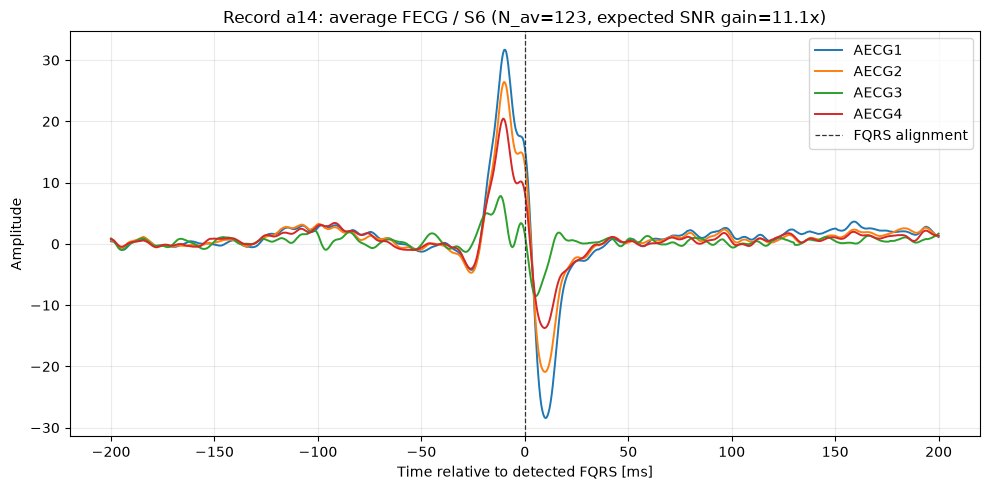

In [6]:
fig, ax = plot_average_fecg(
    record,
    S6,
    fs=fs_s6,
    before_samples=average_result.before_samples,
    used_beats=len(average_result.used_fqrs_samples),
    snr_gain_factor=average_result.snr_gain_factor,
    save_path=PROJECT_ROOT / 'figures' / 'notebook08' / 'a14_average_fecg_s6.png',
)
plt.show()


## Compare individual fetal segments with the average

This plot shows why averaging helps. The gray lines are individual fetal-beat segments, which are noisy. The blue line is the average S6 waveform, which is smoother.

Detail channel: AECG1


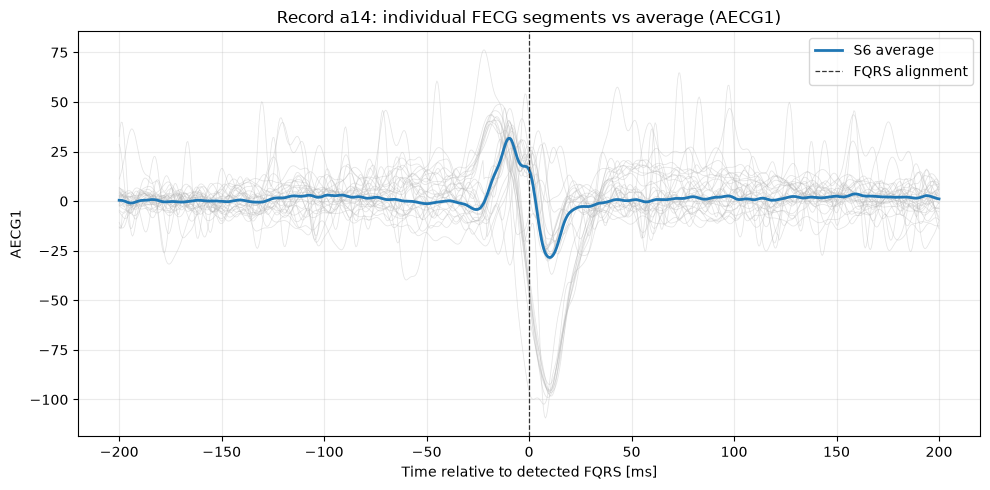

In [7]:
peak_to_peak = np.ptp(S6, axis=0)
detail_channel = int(np.argmax(peak_to_peak))
print(f'Detail channel: {record.channels[detail_channel]}')

fig, ax = plot_fecg_segments_vs_average(
    record,
    average_result.segments,
    S6,
    fs=fs_s6,
    before_samples=average_result.before_samples,
    channel=detail_channel,
    max_segments=30,
    save_path=PROJECT_ROOT / 'figures' / 'notebook08' / 'a14_fecg_segments_vs_average_strongest_channel.png',
)
plt.show()


## Output of this step

`S6` is the average fetal ECG waveform built from the detected fetal QRS positions. It is useful for the final presentation because it shows the fetal ECG morphology more clearly than individual noisy beats.